In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict, train_test_split
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, ConfusionMatrixDisplay

In [2]:
data = pd.read_csv('Titanic-Dataset.csv')

In [3]:
X = data.drop(columns=['Survived'])
y = data['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

numeric_features = ['Age', 'Fare']
X_train[numeric_features] = X_train[numeric_features].fillna(X_train[numeric_features].median())
X_test[numeric_features] = X_test[numeric_features].fillna(X_test[numeric_features].median())

sc = StandardScaler()
X_train[numeric_features] = sc.fit_transform(X_train[numeric_features])
X_test[numeric_features] = sc.transform(X_test[numeric_features])

categorical_features = ['Sex', 'Embarked']
X_train[categorical_features] = X_train[categorical_features].fillna(X_train[categorical_features].mode().iloc[0])
X_test[categorical_features] = X_test[categorical_features].fillna(X_train[categorical_features].mode().iloc[0])

X_train = pd.get_dummies(X_train, columns = categorical_features, dtype=int, drop_first = True)
X_test = pd.get_dummies(X_test, columns = categorical_features, dtype=int, drop_first = True)

X_train.drop(columns = ['Name', 'PassengerId',  'Cabin','SibSp', 'Parch', 'Ticket'], inplace = True)
X_test.drop(columns = ['Name', 'PassengerId',  'Cabin','SibSp', 'Parch', 'Ticket'], inplace = True)

In [5]:
#Print classification report: precision, recall, F1 for each class
kf = KFold(n_splits=5, shuffle=True, random_state=42)

model = LogisticRegression()
scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='accuracy')
print(f'Cross-validation accuracy scores: {scores}')
print(f'Average Accuracy: {np.mean(scores):.4f}')

model.fit(X_train, y_train)
test_accuracy = model.score(X_test, y_test)
print(f"Test set accuracy: {test_accuracy:.4f}")


train_accuracy = model.score(X_train, y_train)
print(f"Train set accuracy: {train_accuracy:.4f}")

y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print("Precision score is", precision_score(y_test, y_pred))
print("Recall score is", recall_score(y_test, y_pred))
print("F1 Score is", f1_score(y_test, y_pred))

Cross-validation accuracy scores: [0.80263158 0.77631579 0.8013245  0.76821192 0.74834437]
Average Accuracy: 0.7794
Test set accuracy: 0.8060
Train set accuracy: 0.7886
Precision score is 0.7777777777777778
Recall score is 0.75
F1 Score is 0.7636363636363637


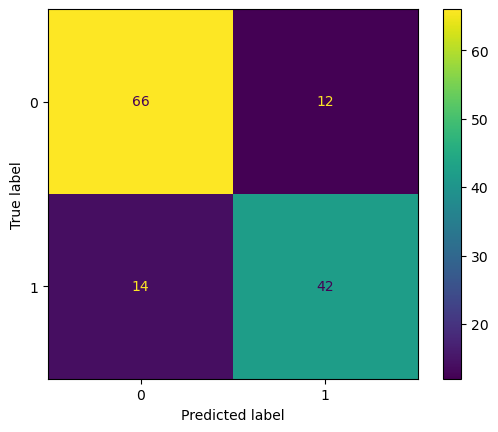

In [6]:
#Q3) Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=model.classes_)
disp.plot()
plt.show()

In [7]:
#Q4) Print coefficients — identify top 3 most important features
order = np.argsort(abs(model.coef_[0]), axis = None)
order_feature_importance = []
for i,j in enumerate(order):
    order_feature_importance.append((model.feature_names_in_[order[i]], model.coef_[0][order[i]]))
print("Coefficients are " , order_feature_importance)
top_3 = []
for i in order_feature_importance[-3:]:
    top_3.append(i[0])

print("\n Top 3 important features are", top_3[::-1])

Coefficients are  [('Fare', np.float64(0.02091278411970295)), ('Embarked_Q', np.float64(-0.10674785841022644)), ('Age', np.float64(-0.3378060322418873)), ('Embarked_S', np.float64(-0.4875887905431722)), ('Pclass', np.float64(-1.058588719166459)), ('Sex_male', np.float64(-2.4725757255518777))]

 Top 3 important features are ['Sex_male', 'Pclass', 'Embarked_S']


In [8]:
#Q5) Try L1 vs L2 penalty and compare results

#l1

model = LogisticRegression(penalty = 'l1', solver = 'liblinear', random_state = 42)
scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='accuracy')
print(f'Cross-validation accuracy scores with L1 penalty: {scores}')
print(f'Average Accuracy with L1 penalty: {np.mean(scores):.4f}')

model.fit(X_train, y_train)
test_accuracy = model.score(X_test, y_test)
print(f"Test set accuracy with L1 penalty: {test_accuracy:.4f}")


train_accuracy = model.score(X_train, y_train)
print(f"Train set accuracy with L1 penalty: {train_accuracy:.4f}")

order = np.argsort(abs(model.coef_[0]), axis = None)
order_feature_importance = []
for i,j in enumerate(order):
    order_feature_importance.append((model.feature_names_in_[order[i]], model.coef_[0][order[i]]))
print("Coefficients are " , order_feature_importance)
top_3 = []
for i in order_feature_importance[-3:]:
    top_3.append(i[0])

print("\n Top 3 important features are", top_3[::-1])

print()

model = LogisticRegression(penalty = 'l2', solver = 'liblinear', random_state = 42)
scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='accuracy')
print(f'Cross-validation accuracy scores with L2 penalty: {scores}')
print(f'Average Accuracy with L2 penalty: {np.mean(scores):.4f}')

model.fit(X_train, y_train)
test_accuracy = model.score(X_test, y_test)
print(f"Test set accuracy with L2 penalty: {test_accuracy:.4f}")


train_accuracy = model.score(X_train, y_train)
print(f"Train set accuracy with L2 penalty: {train_accuracy:.4f}")

order = np.argsort(abs(model.coef_[0]), axis = None)
order_feature_importance = []
for i,j in enumerate(order):
    order_feature_importance.append((model.feature_names_in_[order[i]], model.coef_[0][order[i]]))
print("Coefficients are " , order_feature_importance)
top_3 = []
for i in order_feature_importance[-3:]:
    top_3.append(i[0])

print("\n Top 3 important features are", top_3[::-1])

Cross-validation accuracy scores with L1 penalty: [0.80921053 0.79605263 0.79470199 0.77483444 0.74834437]
Average Accuracy with L1 penalty: 0.7846
Test set accuracy with L1 penalty: 0.7985
Train set accuracy with L1 penalty: 0.7939
Coefficients are  [('Embarked_Q', np.float64(0.0)), ('Fare', np.float64(0.032925525546130735)), ('Age', np.float64(-0.3220759225268516)), ('Embarked_S', np.float64(-0.39403143473090124)), ('Pclass', np.float64(-1.0274318769262931)), ('Sex_male', np.float64(-2.4893069699822434))]

 Top 3 important features are ['Sex_male', 'Pclass', 'Embarked_S']

Cross-validation accuracy scores with L2 penalty: [0.80921053 0.77631579 0.78807947 0.8013245  0.74834437]
Average Accuracy with L2 penalty: 0.7847
Test set accuracy with L2 penalty: 0.8060
Train set accuracy with L2 penalty: 0.7952
Coefficients are  [('Embarked_Q', np.float64(-0.028220423293394133)), ('Fare', np.float64(0.08883953006236359)), ('Age', np.float64(-0.301734854909692)), ('Embarked_S', np.float64(-0.34